# TraceWin distribution viewer

This notebook reads TraceWin binary `.dst` distributions and plots the transverse phase spaces.

Set `TRACEWIN_WORKSPACE` at the beginning of the first code cell. The notebook then reads that workspace's `calc/` directory.
The first plot shows the complete input distribution (`16O5.dst`). `part_rfq.dst` is intentionally excluded. Each figure also reports the beam-state features.
Run all cells after each TraceWin/PARTRAN run so the files are reloaded from disk.

In [1]:
# Basic imports.
import os
import re
import sys
from datetime import datetime
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', '/tmp/beam_optimization_matplotlib')

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# USER CONFIGURATION: pass the TraceWin workspace to visualize here.
# The workspace must contain calc/partran1.out and calc/*.dst.
TRACEWIN_WORKSPACE = Path(
    r'/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace'
).expanduser().resolve()
CALC_SUBDIR = 'calc'
IMAGE_OUTPUT_DIR = TRACEWIN_WORKSPACE / 'distribution_plots'
# -----------------------------------------------------------------------------

# Make the beam_optimization package importable when this notebook is run directly.
def find_project_root(start_path=None):
    start = Path.cwd() if start_path is None else Path(start_path).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'beam_optimization' / '__init__.py').exists():
            return candidate
    raise FileNotFoundError(
        'Could not find the repository root containing beam_optimization/__init__.py. '
        'Start Jupyter from the rl_beam_optimization repository or set PROJECT_ROOT manually.'
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


def safe_filename(text):
    return re.sub(r'[^A-Za-z0-9_.-]+', '_', str(text)).strip('_')


IMAGE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from beam_optimization.env.tracewin_env.tracewin.visualization import (
    find_final_tracewin_dst_path,
    plot_tracewin_distribution,
    plot_tracewin_distribution_with_state,
    tracewin_distribution_from_dst,
)
from beam_optimization.config.adige import BEAM_STATE_FEATURES, score

CALC_DIR = TRACEWIN_WORKSPACE / CALC_SUBDIR


def calc_dir_is_valid(path):
    return (path / 'partran1.out').exists() and any(path.glob('*.dst'))


if not calc_dir_is_valid(CALC_DIR):
    message = (
        'No TraceWin calc directory with partran1.out and .dst files found.\n'
        'Run TraceWin with calc_dir set to the workspace calc directory, then rerun this cell.\n'
        f'Searched:\n  - {CALC_DIR}'
    )
    raise FileNotFoundError(message)

# Complete input distribution. part_rfq.dst is intentionally not plotted.
DST_RESERVOIR = TRACEWIN_WORKSPACE / '16O5.dst'
DST_OUTPUT = find_final_tracewin_dst_path(CALC_DIR)
PARTRAN_FILE = CALC_DIR / 'partran1.out'

# Print the exact files used, so it is obvious which TraceWin run is being plotted.
if not DST_RESERVOIR.exists():
    raise FileNotFoundError(f'Complete input reservoir not found: {DST_RESERVOIR}')
print(f'WORKSPACE   = {TRACEWIN_WORKSPACE}')
print(f'CALC_DIR    = {CALC_DIR}')
print(f'DST_INPUT   = {DST_RESERVOIR}  (complete input distribution)')
print(f'DST_OUTPUT  = {DST_OUTPUT}')
print(f'PARTRAN_OUT = {PARTRAN_FILE}')
print(f'PNG_OUTPUT  = {IMAGE_OUTPUT_DIR}')

WORKSPACE   = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace
CALC_DIR    = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc
DST_INPUT   = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/16O5.dst  (complete input distribution)
DST_OUTPUT  = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/part_dtl1.dst
PARTRAN_OUT = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/calc/partran1.out
PNG_OUTPUT  = /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots


In [2]:
def natural_key(path):
    # Sort filenames naturally: 2.dst comes before 11.dst.
    parts = re.split(r'(\d+)', Path(path).name)
    return [int(part) if part.isdigit() else part.lower() for part in parts]


def read_npart_simulated(partran_file):
    # Read the number of simulated macro-particles from the partran1.out header.
    with open(partran_file) as f:
        f.readline()
        values = f.readline().split()
    return int(values[-1])


NPART_SIMULATED = read_npart_simulated(PARTRAN_FILE)

# Intermediate distributions are every .dst file written in calc/ by PLOT_DST,
# excluding TraceWin's standard input/output names and the selected final output.
excluded_names = {'part_rfq.dst', 'part_dtl1.dst'}
intermediate_files = [
    path for path in sorted(CALC_DIR.glob('*.dst'), key=natural_key)
    if path.name not in excluded_names and path != DST_OUTPUT
]

# Plot order: complete input, PLOT_DST snapshots, final output.
distribution_files = [DST_RESERVOIR, *intermediate_files]
if DST_OUTPUT is not None:
    distribution_files.append(DST_OUTPUT)

missing_files = [path for path in distribution_files if not path.exists()]
if missing_files:
    print('Skipped missing distribution files:')
    for path in missing_files:
        print(f'  {path}')
distribution_files = [path for path in distribution_files if path.exists()]

distributions = []
for path in distribution_files:
    role = (
        'reservoir' if path == DST_RESERVOIR
        else 'output' if path == DST_OUTPUT
        else 'intermediate'
    )

    # Figure title: explicit names for the endpoints; raw filename for intermediate PLOT_DST files.
    display_title = {
        'reservoir': 'Initial input distribution 16O5.dst',
        'output': 'Output distribution AD.BI.05',
        'intermediate': path.name,
    }[role]

    distribution = tracewin_distribution_from_dst(path)
    distributions.append({
        'title': display_title,
        'filename': path.name,
        'role': role,
        'path': path,
        'distribution': distribution,
        'n_particles': len(distribution['x']),
    })

print(f'NPART_SIMULATED = {NPART_SIMULATED:,}')
print('Loaded distributions:')
for item in distributions:
    modified = datetime.fromtimestamp(item['path'].stat().st_mtime)
    print(f"  {item['title']:<20} {item['filename']:<14} {item['role']:<12} {item['n_particles']:>10,} particles   modified: {modified}")


NPART_SIMULATED = 10,000
Loaded distributions:
  Initial input distribution 16O5.dst 16O5.dst       reservoir       159,682 particles   modified: 2026-07-07 17:53:36
  AD.BI.04.dst         AD.BI.04.dst   intermediate      7,532 particles   modified: 2026-07-17 21:14:27.604742
  Output distribution AD.BI.05 part_dtl1.dst  output            3,633 particles   modified: 2026-07-17 21:14:32.165796


In [3]:
# Distribution plotting is centralized in:
# beam_optimization.env.tracewin_env.tracewin.visualization.plot_tracewin_distribution
# The same function is used by TraceWinEnv.render_final_beam_distribution().


In [4]:
# partran1.out contains element-by-element beam statistics.
# Besides the envelope, it provides the exact state features associated with each .dst.
def read_partran_table(partran_file):
    with open(partran_file) as f:
        lines = f.readlines()

    header_line_index = next(
        i for i, line in enumerate(lines)
        if line.lstrip().startswith('##') and 'z(m)' in line
    )
    columns = lines[header_line_index].replace('##', '', 1).split()
    data = np.loadtxt(partran_file, skiprows=header_line_index + 1)

    # TraceWin writes an unnamed first column with the element index before z(m).
    # If we do not account for it, SizeX/SizeY/Aper are shifted by one column.
    if data.ndim == 1:
        data = data.reshape(1, -1)
    if data.shape[1] == len(columns) + 1:
        columns = ['element', *columns]
    elif data.shape[1] != len(columns):
        raise ValueError(
            f'Unexpected partran table shape: {data.shape[1]} values, '
            f'{len(columns)} header columns'
        )
    return {name: data[:, i] for i, name in enumerate(columns)}


partran = read_partran_table(PARTRAN_FILE)
z = partran['z(m)']


def distribution_signature(distribution):
    # Quantities shared by a .dst distribution and partran1.out, in mm/mrad.
    x = np.asarray(distribution['x']) * 1000.0
    y = np.asarray(distribution['y']) * 1000.0
    xp = np.asarray(distribution['xp']) * 1000.0
    yp = np.asarray(distribution['yp']) * 1000.0
    return {
        'x0': float(np.mean(x)),
        'y0': float(np.mean(y)),
        'SizeX': float(np.std(x)),
        'SizeY': float(np.std(y)),
        "x'0": float(np.mean(xp)),
        "y'0": float(np.mean(yp)),
        'npart': len(x),
    }


MATCH_FEATURES = ('x0', 'y0', 'SizeX', 'SizeY', "x'0", "y'0", 'npart')


def state_features_from_distribution(distribution):
    # Used only for the complete reservoir, which has no row in partran1.out.
    x = np.asarray(distribution['x'], dtype=float) * 1000.0
    y = np.asarray(distribution['y'], dtype=float) * 1000.0
    xp = np.asarray(distribution['xp'], dtype=float) * 1000.0
    yp = np.asarray(distribution['yp'], dtype=float) * 1000.0

    def rms_emittance(position, angle):
        covariance = np.mean((position - position.mean()) * (angle - angle.mean()))
        determinant = np.var(position) * np.var(angle) - covariance ** 2
        return float(np.sqrt(max(determinant, 0.0)))

    return {
        'npart_ratio': 1.0,
        'x0': float(x.mean()), 'y0': float(y.mean()),
        'SizeX': float(x.std()), 'SizeY': float(y.std()),
        'ex': rms_emittance(x, xp), 'ey': rms_emittance(y, yp),
        "x'0": float(xp.mean()), "y'0": float(yp.mean()),
    }


def matching_partran_row(distribution, role):
    # Endpoints are known exactly. PLOT_DST snapshots are matched to the closest
    # partran row after normalizing features with different physical units.
    if role == 'output':
        return len(z) - 1

    signature = distribution_signature(distribution)
    distances = np.zeros(len(z), dtype=float)
    for feature in MATCH_FEATURES:
        values = np.asarray(partran[feature], dtype=float)
        scale = max(float(np.nanstd(values)), 1e-9)
        distances += ((values - signature[feature]) / scale) ** 2
    return int(np.nanargmin(distances))


for item in distributions:
    if item['role'] == 'reservoir':
        item['partran_row'] = None
        item['marker'] = None
        item['z_m'] = None
        item['state_source'] = 'calculated from complete input .dst (geometric RMS emittance)'
        item['state_features'] = state_features_from_distribution(item['distribution'])
        continue

    row_index = matching_partran_row(item['distribution'], item['role'])
    item['partran_row'] = row_index
    item['marker'] = int(partran['element'][row_index])
    item['z_m'] = float(z[row_index])
    item['state_source'] = (
        f"partran1.out | marker {item['marker']} | z = {item['z_m']:.6g} m"
    )
    item['state_features'] = {
        feature: (
            float(partran['npart'][row_index]) / NPART_SIMULATED
            if feature == 'npart_ratio'
            else float(partran[feature][row_index])
        )
        for feature in BEAM_STATE_FEATURES
    }

# Use the same score function as SurrogateEnv and TraceWinEnv.
for item in distributions:
    item['score'] = score(item['state_features'])

TUBE_RADIUS_MM = float(np.nanmax(partran['Aper']))
PLOT_XY_RANGE_MM = TUBE_RADIUS_MM  # Use 50.0 here for a zoomed beam view.
PLOT_ANGLE_RANGE_MRAD = float(np.ceil(max(
    np.nanmax(np.abs(item['distribution'][key] * 1000.0))
    for item in distributions
    for key in ('xp', 'yp')
) / 10.0) * 10.0)

print(f'Loaded {len(z)} rows from {PARTRAN_FILE.name}')
print(f'TUBE_RADIUS_MM = {TUBE_RADIUS_MM:g}')
print(f'PLOT_XY_RANGE_MM = {PLOT_XY_RANGE_MM:g}')
print(f'PLOT_ANGLE_RANGE_MRAD = {PLOT_ANGLE_RANGE_MRAD:g}')
print('Matched beam states:')
for item in distributions:
    print(f"  {item['filename']:<14} -> {item['state_source']}")

Loaded 984 rows from partran1.out
TUBE_RADIUS_MM = 550
PLOT_XY_RANGE_MM = 550
PLOT_ANGLE_RANGE_MRAD = 30
Matched beam states:
  16O5.dst       -> calculated from complete input .dst (geometric RMS emittance)
  AD.BI.04.dst   -> partran1.out | marker 113 | z = 2.822 m
  part_dtl1.dst  -> partran1.out | marker 335 | z = 10.4171 m


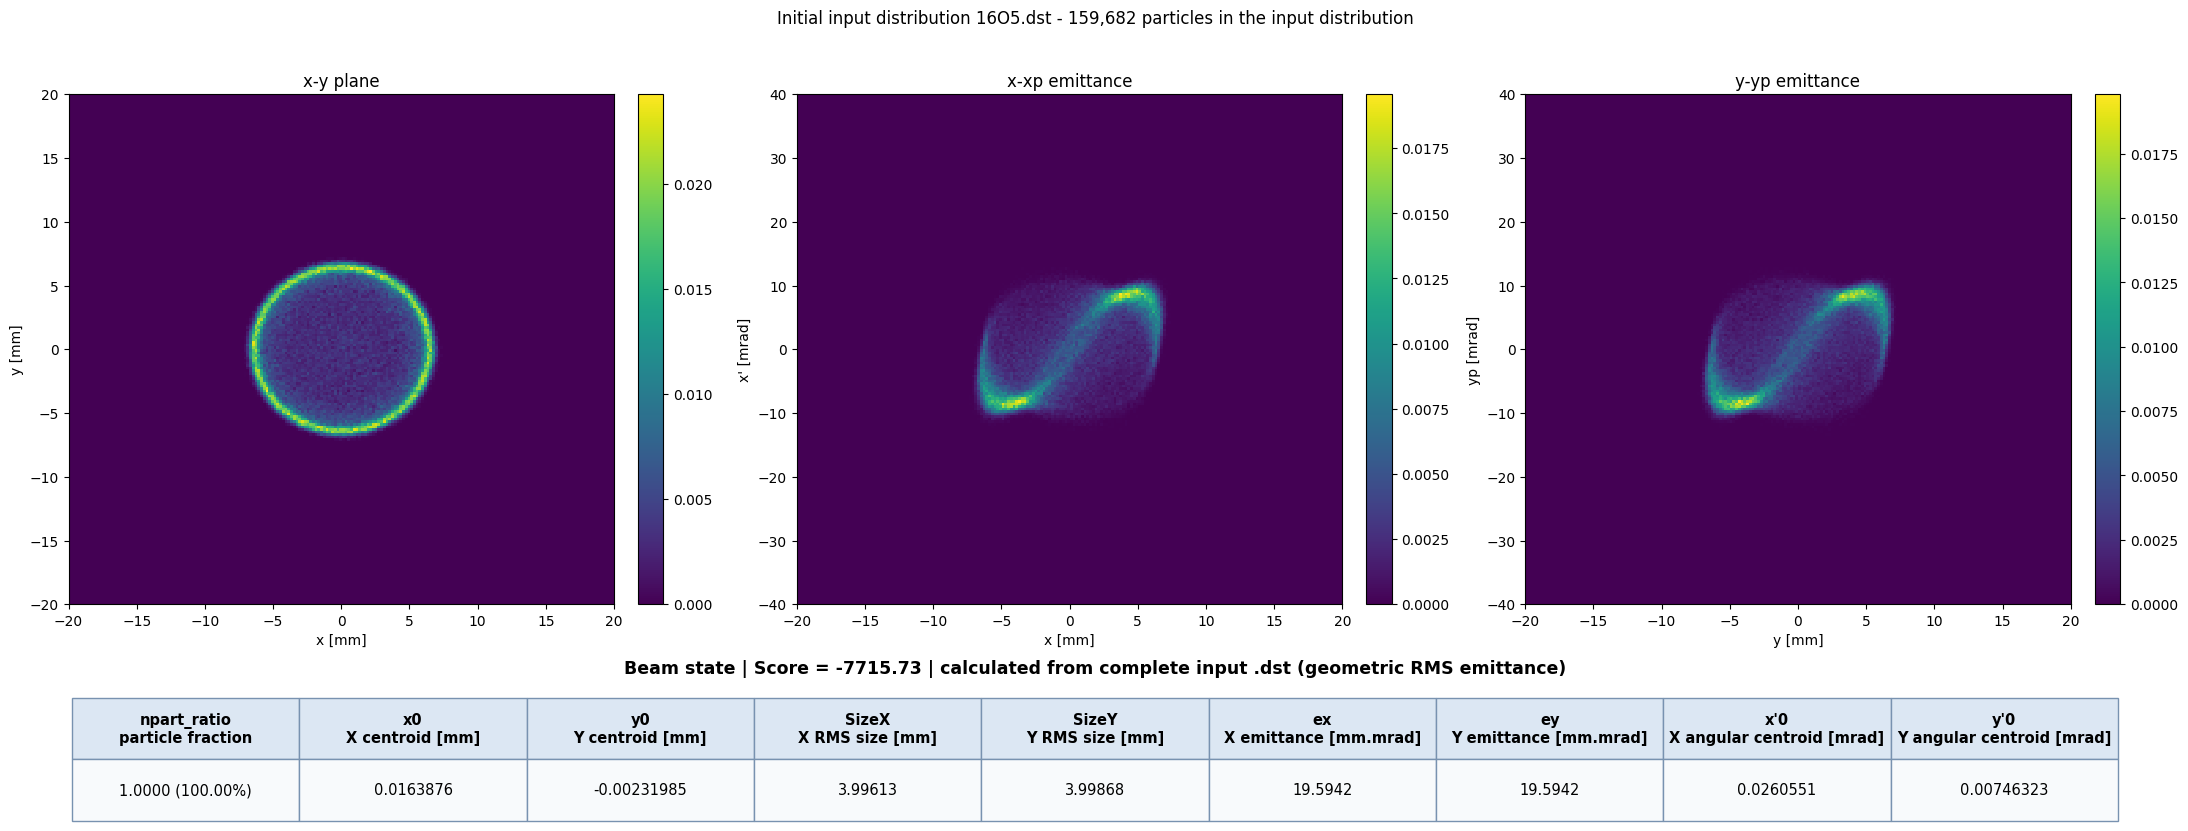

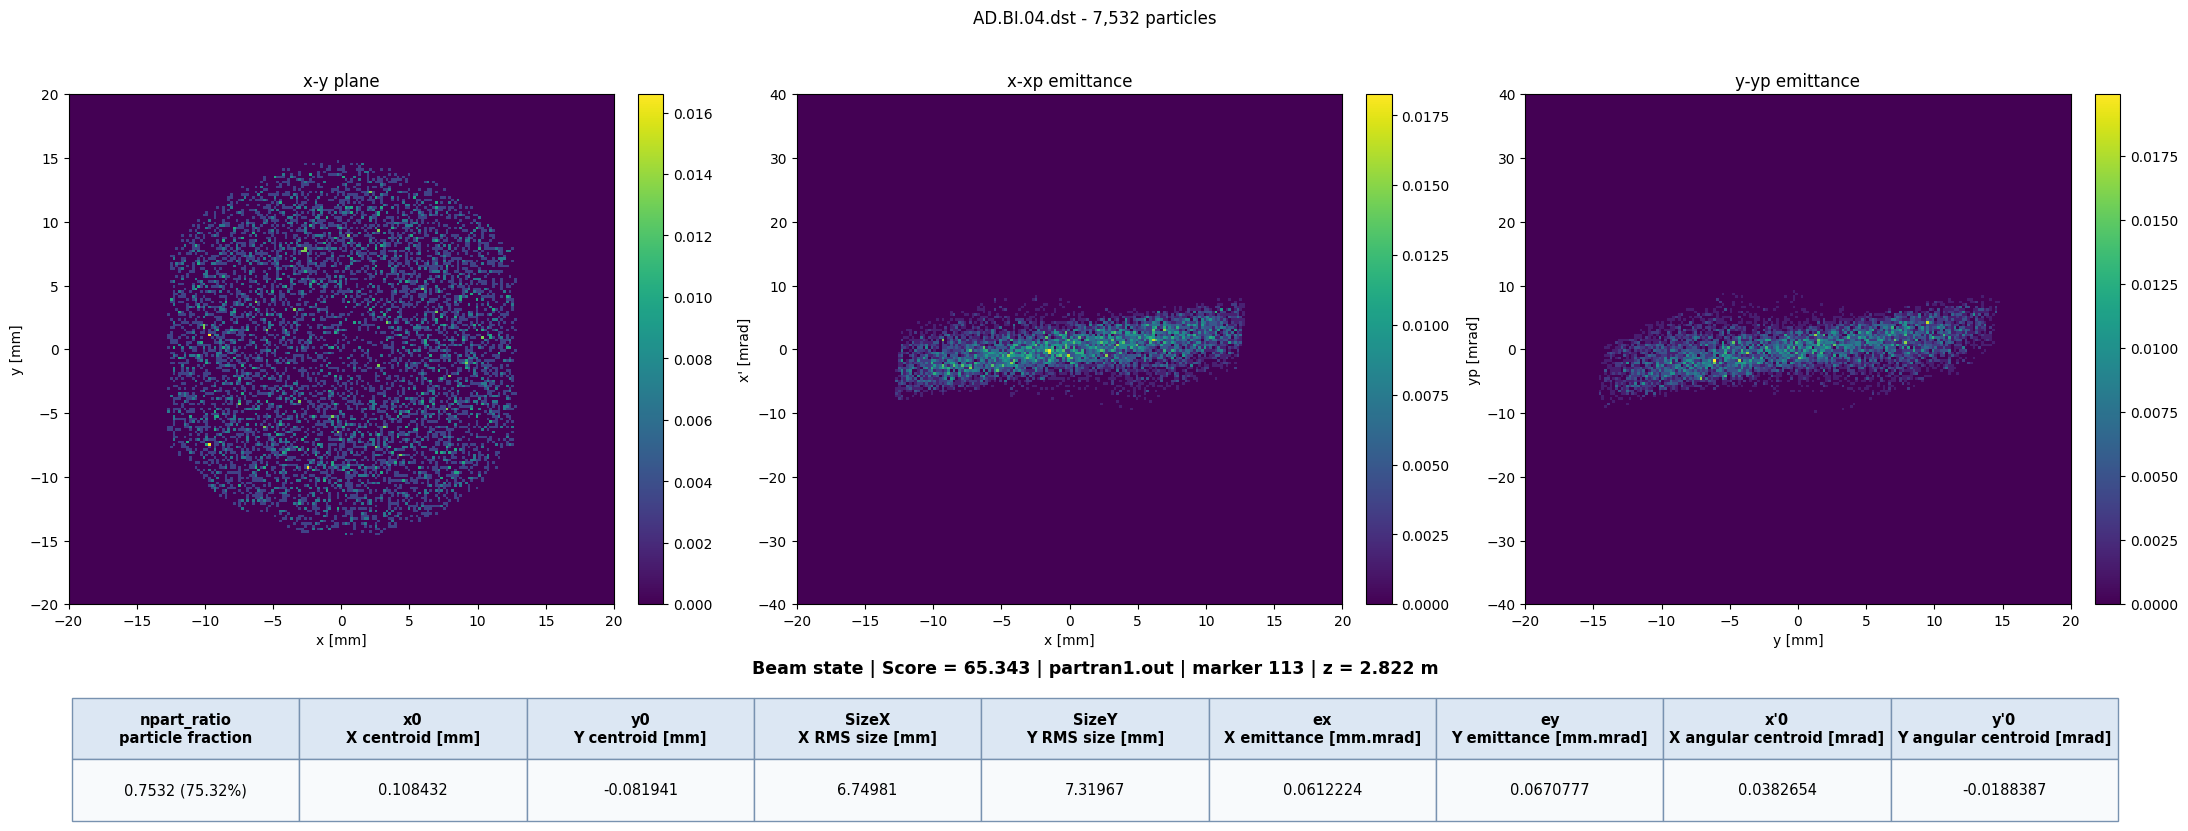

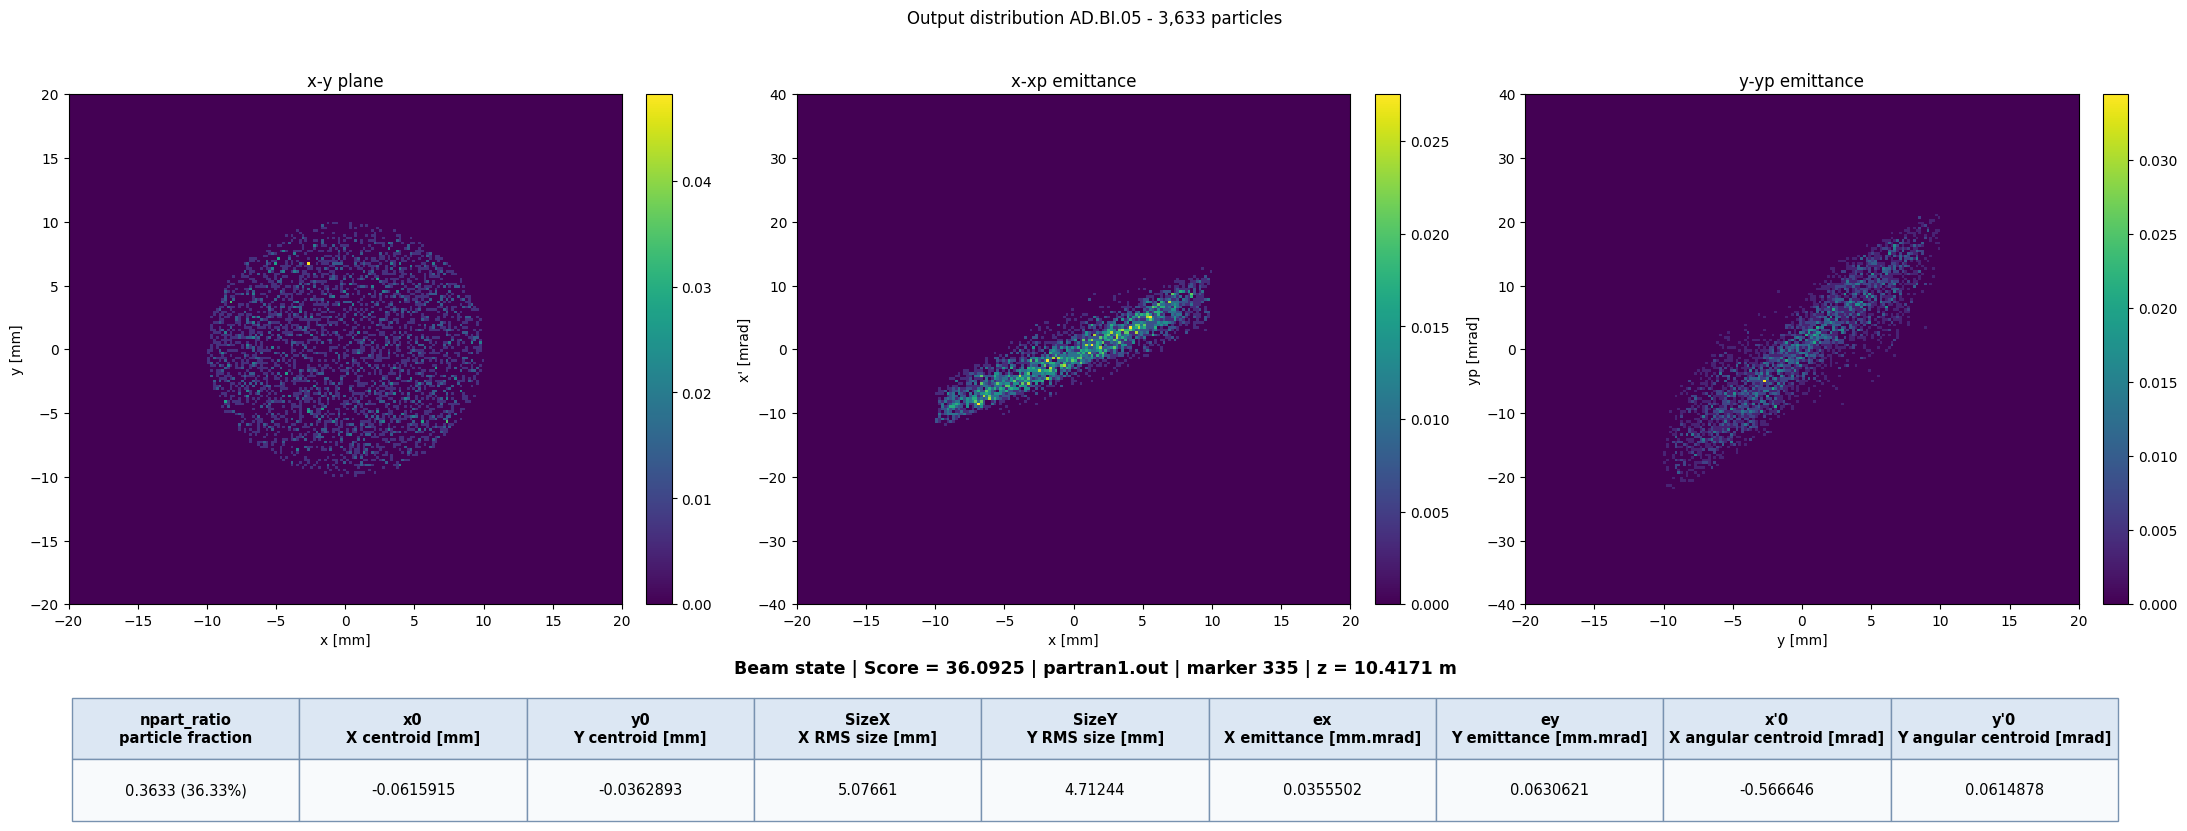

Saved distribution figures:
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_00_16O5.dst.png
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_01_AD.BI.04.dst.png
  /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/distribution_02_part_dtl1.dst.png


In [5]:
# Draw one figure for each distribution.
# Input/output use readable endpoint titles; intermediate snapshots use their calc filename.
saved_distribution_figures = []

for i, item in enumerate(distributions):
    if item['role'] == 'reservoir':
        subtitle = f"{item['n_particles']:,} particles in the input distribution"
    elif item['role'] == 'output':
        subtitle = f"{item['n_particles']:,} particles"
    else:
        subtitle = f"{item['n_particles']:,} particles"

    save_path = IMAGE_OUTPUT_DIR / f"distribution_{i:02d}_{safe_filename(item['filename'])}.png"
    fig = plot_tracewin_distribution_with_state(
        item['distribution'],
        item['state_features'],
        item['score'],
        state_source=item['state_source'],
        title=f"{item['title']} - {subtitle}",
        figure_name=f"TraceWin distribution - {item['filename']}",
        bins=200,
        xy_range_mm=20,
        angle_range_mrad=40,
        aperture_radius_mm=None,
        figsize=(22, 8.5),
        save_path=save_path,
        show=False,
    )
    plt.show()
    saved_distribution_figures.append(save_path)

print('Saved distribution figures:')
for path in saved_distribution_figures:
    print(f'  {path}')


## Envelope plot

Saved envelope figure: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/tracewin_env/tracewin/TraceWin_workspace/distribution_plots/beam_rms_envelope.png


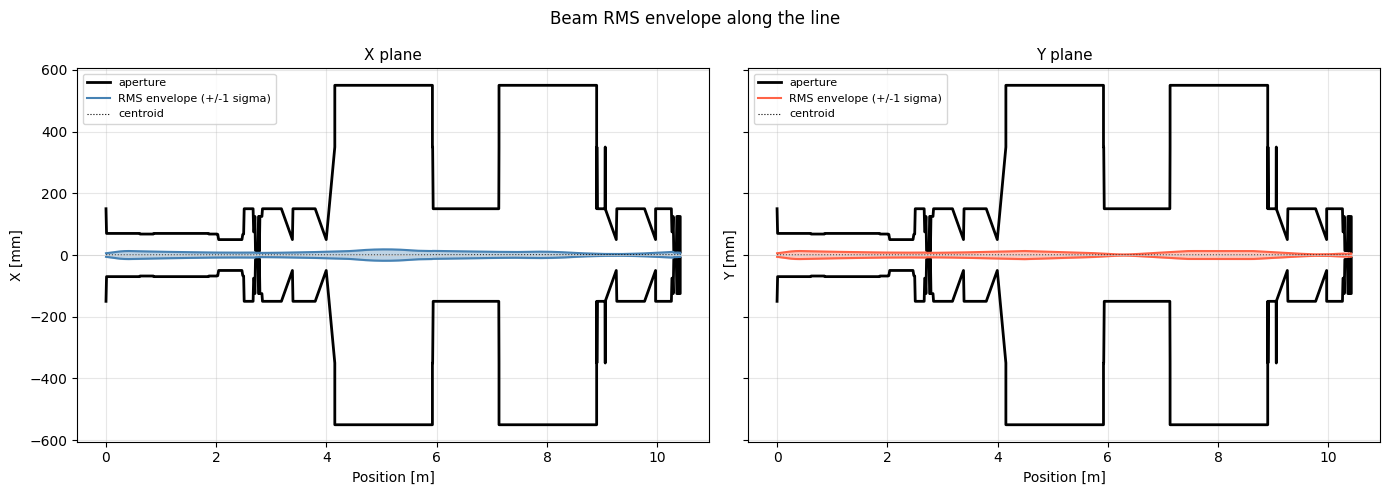

In [6]:
# Envelope plot from partran1.out.
# Black curves are aperture walls; colored bands show centroid +/- RMS size.
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, plane, centroid_col, size_col, color in [
    (axes[0], 'X', 'x0', 'SizeX', 'steelblue'),
    (axes[1], 'Y', 'y0', 'SizeY', 'tomato'),
]:
    c0 = partran[centroid_col]
    size = partran[size_col]
    aper = partran['Aper']

    ax.plot(z, aper, color='black', linewidth=2.0, label='aperture')
    ax.plot(z, -aper, color='black', linewidth=2.0)

    ax.fill_between(z, c0 - size, c0 + size, alpha=0.35, color=color)
    ax.plot(z, c0 + size, color=color, linewidth=1.5, label='RMS envelope (+/-1 sigma)')
    ax.plot(z, c0 - size, color=color, linewidth=1.5)
    ax.plot(z, c0, color='black', linewidth=0.8, linestyle=':', label='centroid')

    ax.axhline(0, color='lightgray', lw=0.5)
    ax.set_xlabel('Position [m]', fontsize=10)
    ax.set_ylabel(f'{plane} [mm]', fontsize=10)
    ax.set_title(f'{plane} plane', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Beam RMS envelope along the line', fontsize=12)
plt.tight_layout()
envelope_path = IMAGE_OUTPUT_DIR / 'beam_rms_envelope.png'
fig.savefig(envelope_path, dpi=160)
print(f'Saved envelope figure: {envelope_path}')
plt.show()